In [ ]:
from pathlib import Path
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
print('Текущая рабочая папка:', PROJECT_DIR)
data_json = PROJECT_DIR / 'data.json'
if data_json.exists():
    print('data.json найден')
else:
    print('data.json не найден — если запускаете ноутбук 01, положите его в текущую папку проекта:', PROJECT_DIR)
existing = sorted(p.name for p in ARTIFACT_DIR.iterdir())
if existing:
    print(f'В artifacts/ уже есть {len(existing)} файлов/папок:')
    for name in existing:
        print(' -', name)
else:
    print('Папка artifacts/ пока пустая, она заполнится после запуска обучающих ноутбуков.')

# 04 — Deep Learning: Fine-tuning RuBERT на датасете с использованием PyTorch


### Проверка зависимостей

In [2]:
import importlib.util
import subprocess
import sys
REQUIRED_PACKAGES = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'datasets': 'datasets',
    'transformers': 'transformers',
    'torch': 'torch',
    'tqdm': 'tqdm',
    'joblib': 'joblib'}
missing = [pkg for module, pkg in REQUIRED_PACKAGES.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Устанавливаются отсутствующие зависимости:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('Все зависимости доступны.')

Все зависимости доступны.


## Импорты и конфигурация

In [3]:
import json
import os
import random
import re
import warnings
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
RANDOM_STATE = 42
PROJECT_DIR = Path.cwd()
ARTIFACT_DIR = PROJECT_DIR / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_NAMES = ['Негативный', 'Позитивный', 'Нейтральный']
LABEL2NAME = {0: 'Негативный', 1: 'Позитивный', 2: 'Нейтральный'}
ID2LABEL = {0: 'NEGATIVE', 1: 'POSITIVE', 2: 'NEUTRAL'}
LABEL2ID = {'NEGATIVE': 0, 'POSITIVE': 1, 'NEUTRAL': 2}
TOXIC_KEYWORDS = ['депрессия', 'грусть', 'боль', 'слезы', 'слёзы', 'одиночество','апатия', 'ненависть', 'суицид', 'смерть', 'безысходность']
sns.set_theme(style='whitegrid', palette='Set2')
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
set_seed(RANDOM_STATE)
print(f'Рабочая папка: {PROJECT_DIR}')
print(f'Папка артефактов: {ARTIFACT_DIR}')
import gc
from copy import deepcopy
import joblib
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import train_test_split
from transformers import AutoConfig, AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(RANDOM_STATE)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()} | Device: {DEVICE}')

Рабочая папка: /content/drive/MyDrive/happiness_formula
Папка артефактов: /content/drive/MyDrive/happiness_formula/artifacts
PyTorch: 2.11.0+cu128
CUDA available: True | Device: cuda


## 7. Fine-tuning RuBERT

In [4]:
RUBERT_MODEL_NAME = 'DeepPavlov/rubert-base-cased'
RUBERT_MAX_LENGTH = 192
RUBERT_BATCH_SIZE = 16 if DEVICE.type == 'cuda' else 8
class RuBERTSentimentDataset(Dataset):
    def __init__(self, texts: List[str], labels: List[int], tokenizer, max_length: int):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length
    def __len__(self) -> int:
        return len(self.texts)
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt')
        item = {key: value.squeeze(0) for key, value in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item
def make_rubert_loader(texts: List[str], labels: List[int], tokenizer, max_length: int, batch_size: int, shuffle: bool) -> DataLoader:
    dataset = RuBERTSentimentDataset(texts, labels, tokenizer, max_length)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=(DEVICE.type == 'cuda'))
@torch.no_grad()
def evaluate_rubert_model(model: nn.Module, data_loader: DataLoader, loss_fn=None) -> Dict[str, object]:
    model.eval()
    losses, predictions, targets = [], [], []
    for batch in data_loader:
        labels = batch.pop('labels').to(DEVICE)
        inputs = {key: value.to(DEVICE) for key, value in batch.items()}
        logits = model(**inputs).logits
        if loss_fn is not None:
            losses.append(loss_fn(logits, labels).item())
        predictions.extend(torch.argmax(logits, dim=1).detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    return {
        'loss': float(np.mean(losses)) if losses else np.nan,
        'f1_weighted': f1_score(targets, predictions, average='weighted'),
        'accuracy': accuracy_score(targets, predictions),
        'preds': predictions,
        'targets': targets}
def build_rubert_model(dropout: float, model_name: str = RUBERT_MODEL_NAME) -> nn.Module:
    config = AutoConfig.from_pretrained(
        model_name,
        num_labels=3,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        hidden_dropout_prob=dropout,
        attention_probs_dropout_prob=dropout)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True)
    return model.to(DEVICE)
def train_rubert_torch(
    train_texts: List[str],
    train_labels: List[int],
    valid_texts: List[str],
    valid_labels: List[int],
    *,
    learning_rate: float,
    dropout: float,
    weight_decay: float,
    epochs: int,
    batch_size: int,
    warmup_ratio: float = 0.10,
    use_amp: bool = True,
    checkpoint_path: Optional[Path] = None,
    resume: bool = True) -> Tuple[nn.Module, pd.DataFrame, Dict[str, object]]:
    set_seed(RANDOM_STATE)
    model = build_rubert_model(dropout=dropout)
    train_loader = make_rubert_loader(train_texts, train_labels, rubert_tokenizer, RUBERT_MAX_LENGTH, batch_size, True)
    valid_loader = make_rubert_loader(valid_texts, valid_labels, rubert_tokenizer, RUBERT_MAX_LENGTH, batch_size, False)
    class_counts = np.bincount(train_labels, minlength=3)
    class_weights = len(train_labels) / (3 * np.maximum(class_counts, 1))
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float32, device=DEVICE))
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    total_steps = max(1, len(train_loader) * epochs)
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    amp_enabled = use_amp and DEVICE.type == 'cuda'
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)
    start_epoch = 1
    best_state = None
    best_valid_f1 = -1.0
    best_metrics = {}
    history = []
    if checkpoint_path is not None and resume and Path(checkpoint_path).exists():
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        scheduler.load_state_dict(checkpoint['scheduler_state'])
        scaler.load_state_dict(checkpoint['scaler_state'])
        start_epoch = checkpoint['epoch'] + 1
        best_valid_f1 = checkpoint['best_valid_f1']
        best_metrics = checkpoint['best_metrics']
        best_state = checkpoint['best_state']
        history = checkpoint['history']
        print(
            f"Восстановлено из чекпоинта {checkpoint_path}: завершена эпоха "
            f"{checkpoint['epoch']}, продолжаем с эпохи {start_epoch}/{epochs}")
    for epoch in range(start_epoch, epochs + 1):
        model.train()
        train_losses = []
        for batch in tqdm(train_loader, desc=f'RuBERT epoch {epoch}/{epochs}', leave=False):
            labels = batch.pop('labels').to(DEVICE)
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=amp_enabled):
                logits = model(**inputs).logits
                loss = loss_fn(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            train_losses.append(loss.item())
        valid_metrics = evaluate_rubert_model(model, valid_loader, loss_fn)
        row = {
            'epoch': epoch,
            'train_loss': float(np.mean(train_losses)),
            'valid_loss': valid_metrics['loss'],
            'valid_f1_weighted': valid_metrics['f1_weighted'],
            'valid_accuracy': valid_metrics['accuracy']}
        history.append(row)
        print(
            f"Epoch {epoch}: train_loss={row['train_loss']:.4f} | "
            f"valid_loss={row['valid_loss']:.4f} | "
            f"valid_f1={row['valid_f1_weighted']:.4f} | "
            f"valid_acc={row['valid_accuracy']:.4f}")
        if valid_metrics['f1_weighted'] > best_valid_f1:
            best_valid_f1 = valid_metrics['f1_weighted']
            best_metrics = valid_metrics
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        if checkpoint_path is not None:
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_state': scheduler.state_dict(),
                'scaler_state': scaler.state_dict(),
                'best_valid_f1': best_valid_f1,
                'best_metrics': best_metrics,
                'best_state': best_state,
                'history': history}, checkpoint_path)
            print(f'Чекпоинт сохранён: {checkpoint_path} (эпоха {epoch}/{epochs})')
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_metrics
@torch.no_grad()
def predict_rubert_sentiment(model: nn.Module, tokenizer, texts: List[str], batch_size: int = RUBERT_BATCH_SIZE) -> Tuple[List[int], List[float]]:
    if isinstance(texts, str):
        texts = [texts]
    loader = make_rubert_loader(texts, [0] * len(texts), tokenizer, RUBERT_MAX_LENGTH, batch_size, False)
    model.eval()
    predictions, confidences = [], []
    for batch in loader:
        batch.pop('labels')
        inputs = {key: value.to(DEVICE) for key, value in batch.items()}
        probabilities = torch.softmax(model(**inputs).logits, dim=1)
        confidence, predicted = torch.max(probabilities, dim=1)
        predictions.extend(predicted.cpu().tolist())
        confidences.extend(confidence.cpu().tolist())
    return predictions, confidences

In [5]:
split_path = ARTIFACT_DIR / '02_sentiment_split.joblib'
if not split_path.exists():
    raise FileNotFoundError('Не найден artifacts/02_sentiment_split.joblib. Сначала запустите файл 02.')
split = joblib.load(split_path)
X_train_raw = split['X_train_raw']
X_test_raw = split['X_test_raw']
y_train = [int(value) for value in split['y_train']]
y_test = [int(value) for value in split['y_test']]
X_rubert_train, X_rubert_valid, y_rubert_train, y_rubert_valid = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=y_train)
rubert_tokenizer = AutoTokenizer.from_pretrained(RUBERT_MODEL_NAME)
print(f'RuBERT train: {len(X_rubert_train)}')
print(f'RuBERT valid: {len(X_rubert_valid)}')
print(f'RuBERT test: {len(X_test_raw)}')
print(f'Batch size: {RUBERT_BATCH_SIZE}')

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.65M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

RuBERT train: 5100
RuBERT valid: 900
RuBERT test: 1500
Batch size: 16


### 7.1 Обучение с базовыми гиперпараметрами

In [6]:
RUBERT_DEFAULT_PARAMS = {
    'learning_rate': 2e-5,
    'dropout': 0.10,
    'weight_decay': 0.01}
RUBERT_FINAL_EPOCHS = 4
rubert_model, rubert_history, rubert_valid_metrics = train_rubert_torch(
    X_rubert_train,
    y_rubert_train,
    X_rubert_valid,
    y_rubert_valid,
    learning_rate=RUBERT_DEFAULT_PARAMS['learning_rate'],
    dropout=RUBERT_DEFAULT_PARAMS['dropout'],
    weight_decay=RUBERT_DEFAULT_PARAMS['weight_decay'],
    epochs=RUBERT_FINAL_EPOCHS,
    batch_size=RUBERT_BATCH_SIZE,
    checkpoint_path=ARTIFACT_DIR / '04_rubert_checkpoint.pt')
test_loader = make_rubert_loader(X_test_raw, y_test, rubert_tokenizer, RUBERT_MAX_LENGTH, RUBERT_BATCH_SIZE, False)
rubert_test_metrics = evaluate_rubert_model(rubert_model, test_loader)
rubert_preds = rubert_test_metrics['preds']
rubert_f1 = rubert_test_metrics['f1_weighted']
rubert_accuracy = rubert_test_metrics['accuracy']
print('Fine-tuned RuBERT, default hyperparameters')
print(classification_report(y_test, rubert_preds, target_names=TARGET_NAMES))
print(f'Weighted F1 RuBERT: {rubert_f1:.4f}')
logreg_metrics_path = ARTIFACT_DIR / '02_logreg_metrics.json'
if logreg_metrics_path.exists():
    with open(logreg_metrics_path, 'r', encoding='utf-8') as file:
        logreg_metrics = json.load(file)
    logreg_f1 = float(logreg_metrics['f1_weighted'])
    print(f'Weighted F1 LogReg: {logreg_f1:.4f}')
    print(f'Разница RuBERT - LogReg: {rubert_f1 - logreg_f1:.4f}')
    if rubert_f1 <= logreg_f1:
        print('Предупреждение: RuBERT ниже LogReg. Проверьте overfitting, LR, размер выборки и доменный сдвиг.')

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those par

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Восстановлено из чекпоинта /content/drive/MyDrive/happiness_formula/artifacts/04_rubert_checkpoint.pt: завершена эпоха 4, продолжаем с эпохи 5/4
Fine-tuned RuBERT, default hyperparameters
              precision    recall  f1-score   support

  Негативный       0.56      0.63      0.59       500
  Позитивный       0.81      0.77      0.79       500
 Нейтральный       0.72      0.66      0.69       500

    accuracy                           0.69      1500
   macro avg       0.70      0.69      0.69      1500
weighted avg       0.70      0.69      0.69      1500

Weighted F1 RuBERT: 0.6909
Weighted F1 LogReg: 0.6185
Разница RuBERT - LogReg: 0.0724


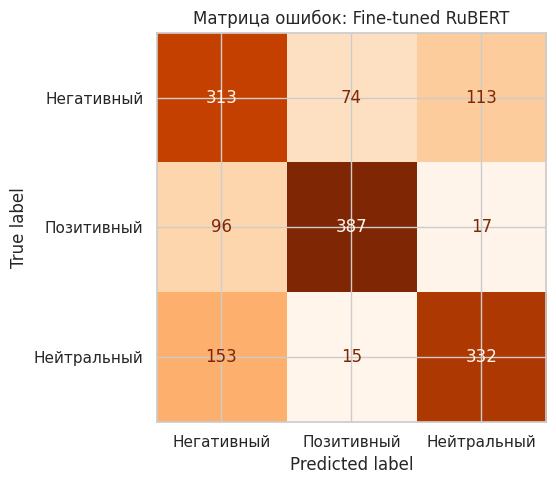

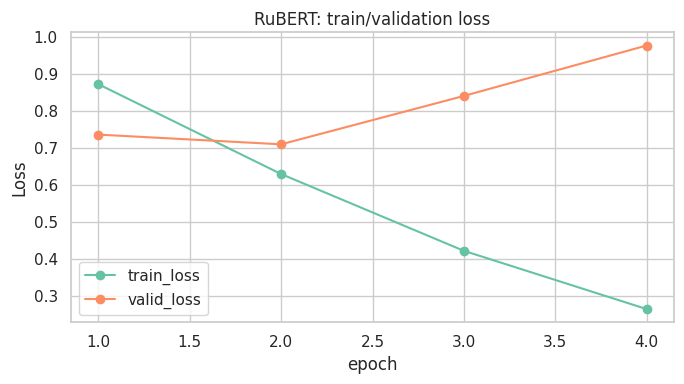

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rubert_preds)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Матрица ошибок: Fine-tuned RuBERT')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / '04_cm_rubert_default.png', dpi=150, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(7, 4))
rubert_history.plot(x='epoch', y=['train_loss', 'valid_loss'], marker='o', ax=ax)
ax.set_title('RuBERT: train/validation loss')
ax.set_ylabel('Loss')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / '04_rubert_loss.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
model_dir = ARTIFACT_DIR / '04_rubert_finetuned_default'
model_dir.mkdir(parents=True, exist_ok=True)
rubert_model.save_pretrained(model_dir)
rubert_tokenizer.save_pretrained(model_dir)
metrics = {
    'model': 'Fine-tuned RuBERT default',
    'type': 'Transformer DL',
    'f1_weighted': float(rubert_f1),
    'accuracy': float(rubert_accuracy),
    'best_valid_f1_weighted': float(rubert_valid_metrics.get('f1_weighted', np.nan)),
    'best_valid_accuracy': float(rubert_valid_metrics.get('accuracy', np.nan)),
    'params': RUBERT_DEFAULT_PARAMS,
    'epochs': RUBERT_FINAL_EPOCHS,
    'model_dir': str(model_dir)}
predictions_df = pd.DataFrame({'text': X_test_raw, 'label_true': y_test, 'label_pred': rubert_preds})
predictions_df['label_true_name'] = predictions_df['label_true'].map(LABEL2NAME)
predictions_df['label_pred_name'] = predictions_df['label_pred'].map(LABEL2NAME)
with open(ARTIFACT_DIR / '04_rubert_default_metrics.json', 'w', encoding='utf-8') as file:
    json.dump(metrics, file, ensure_ascii=False, indent=2)
rubert_history.to_csv(ARTIFACT_DIR / '04_rubert_default_history.csv', index=False, encoding='utf-8-sig')
predictions_df.to_csv(ARTIFACT_DIR / '04_rubert_default_predictions.csv', index=False, encoding='utf-8-sig')
print(f'Fine-tuned RuBERT сохранён в: {model_dir}')
print(json.dumps(metrics, ensure_ascii=False, indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned RuBERT сохранён в: /content/drive/MyDrive/happiness_formula/artifacts/04_rubert_finetuned_default
{
  "model": "Fine-tuned RuBERT default",
  "type": "Transformer DL",
  "f1_weighted": 0.6909051125847459,
  "accuracy": 0.688,
  "best_valid_f1_weighted": 0.692278564875175,
  "best_valid_accuracy": 0.69,
  "params": {
    "learning_rate": 2e-05,
    "dropout": 0.1,
    "weight_decay": 0.01
  },
  "epochs": 4,
  "model_dir": "/content/drive/MyDrive/happiness_formula/artifacts/04_rubert_finetuned_default"
}
